In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [3]:

# 1. Cargar el dataset
df = pd.read_csv('df_preparado_modelado.csv')

# --- TRUCO: Verifica que los nombres coinciden ---
print("Columnas detectadas en el CSV:", df.columns.tolist())

# Asegurar que las columnas categóricas se traten como tales
categorical_cols = ['Provincia', 'tipo_abc', 'codigo_articulo', 'modalidad']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 2. Definir Features (X) y Target (y) con los nombres CORREGIDOS
features = [
    'year', 'week', 'Provincia', 'tipo_abc', 'codigo_articulo', 
    'duracion', 'modalidad', 'hay_prueba', 'clima_temp', 
    'clima_precip', 'clima_viento', 
    'ventas_lag_semanal',  # <--- Cambiado de ventas_lag1 a ventas_lag_semanal
    'ventas_lag_mensual'
]
target = 'unidades'

# 3. Split Temporal
test_threshold_year = 2024
test_threshold_week = 9

train = df[(df['year'] < test_threshold_year) | ((df['year'] == test_threshold_year) & (df['week'] < test_threshold_week))]
test = df[(df['year'] == test_threshold_year) & (df['week'] >= test_threshold_week)]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 4. Configurar y Entrenar el Modelo
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)

print("Entrenando modelo...")
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)

# 5. Predicciones y Métricas
preds = model.predict(X_test)
print(f"\nMAE: {mean_absolute_error(y_test, preds):.4f}")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")

# 6. Resultado Final Agregado por Semana
test['prediccion'] = preds
resultado_semanal = test.groupby('anio_semana')[['unidades', 'prediccion']].sum().reset_index()
print("\n--- RESUMEN DE PREDICCIÓN SEMANAL ---")
print(resultado_semanal)

Columnas detectadas en el CSV: ['anio_semana', 'Provincia', 'tipo_abc', 'codigo_articulo', 'unidades', 'duracion', 'modalidad', 'hay_prueba', 'clima_temp', 'clima_precip', 'clima_viento', 'year', 'week', 'ventas_lag_semanal', 'ventas_lag_mensual']
Entrenando modelo...
[0]	validation_0-rmse:1.84763
[50]	validation_0-rmse:1.68142
[100]	validation_0-rmse:1.68913
[150]	validation_0-rmse:1.69176
[200]	validation_0-rmse:1.69027
[250]	validation_0-rmse:1.69010
[300]	validation_0-rmse:1.69365
[350]	validation_0-rmse:1.70067
[400]	validation_0-rmse:1.70490
[450]	validation_0-rmse:1.71018
[499]	validation_0-rmse:1.71219

MAE: 0.0869
R2 Score: 0.1558

--- RESUMEN DE PREDICCIÓN SEMANAL ---
   anio_semana  unidades   prediccion
0      2024-10    4290.0  4354.142090
1      2024-11    6065.0  3915.548828
2      2024-12    4667.0  4121.965332
3      2024-13     687.0  1597.520996
4      2024-14    3678.0  3646.072266
5      2024-15    3373.0  3545.261230
6      2024-16    3406.0  3761.083008
7      20

C:\Users\03946542\AppData\Local\Temp\ipykernel_5208\58532937.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediccion'] = preds


## ITERACIÓN 2

In [7]:



# 1. Cargar el dataset
df = pd.read_csv('df_preparado_modelado.csv') # Asegúrate de usar el archivo correcto

# --- TRUCO: Verifica que los nombres coinciden ---
print("Columnas detectadas en el CSV:", df.columns.tolist())

# --- NUEVO 1: Estrategia de Filtrado (Quitar el ruido de baja rotación) ---
print(f"Filas totales originales: {len(df)}")
df = df[df['tipo_abc'].isin(['A', 'B'])]
print(f"Filas tras quedarnos solo con superventas (A y B): {len(df)}")

# Asegurar que las columnas categóricas se traten como tales
categorical_cols = ['Provincia', 'tipo_abc', 'codigo_articulo', 'modalidad']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 2. Definir Features (X) y Target (y)
features = [
    'year', 'week', 'Provincia', 'tipo_abc', 'codigo_articulo', 
    'duracion', 'modalidad', 'hay_prueba', 'clima_temp', 
    'clima_precip', 'clima_viento', 
    'ventas_lag_semanal', 
    'ventas_lag_mensual'
]
target = 'unidades'

# 3. Split Temporal 
test_threshold_year = 2024
test_threshold_week = 9

# --- NUEVO 2: Usar .copy() al crear train y test para EVITAR EL WARNING de Pandas ---
train = df[(df['year'] < test_threshold_year) | ((df['year'] == test_threshold_year) & (df['week'] < test_threshold_week))].copy()
test = df[(df['year'] == test_threshold_year) & (df['week'] >= test_threshold_week)].copy()

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 4. Configurar y Entrenar el Modelo
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    early_stopping_rounds=20  # <--- ¡MUDADO AQUÍ! Se pone al crear el modelo
)

print("\nEntrenando modelo...")

# En el fit() ahora solo pasamos el eval_set y el verbose
model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=50
)

# 5. Predicciones y Métricas
preds = model.predict(X_test)
print(f"\nMAE: {mean_absolute_error(y_test, preds):.4f}")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")

# 6. Resultado Final Agregado por Semana
test['prediccion'] = preds
resultado_semanal = test.groupby('anio_semana')[['unidades', 'prediccion']].sum().reset_index()
print("\n--- RESUMEN DE PREDICCIÓN SEMANAL ---")
print(resultado_semanal)

Columnas detectadas en el CSV: ['anio_semana', 'Provincia', 'tipo_abc', 'codigo_articulo', 'unidades', 'duracion', 'modalidad', 'hay_prueba', 'clima_temp', 'clima_precip', 'clima_viento', 'year', 'week', 'ventas_lag_semanal', 'ventas_lag_mensual']
Filas totales originales: 4745026
Filas tras quedarnos solo con superventas (A y B): 3704129

Entrenando modelo...
[0]	validation_0-tweedie-nloglik@1.5:1.46477
[50]	validation_0-tweedie-nloglik@1.5:0.40124
[100]	validation_0-tweedie-nloglik@1.5:0.34422
[150]	validation_0-tweedie-nloglik@1.5:0.33935
[200]	validation_0-tweedie-nloglik@1.5:0.33864
[240]	validation_0-tweedie-nloglik@1.5:0.33857

MAE: 0.0916
R2 Score: 0.2156

--- RESUMEN DE PREDICCIÓN SEMANAL ---
   anio_semana  unidades   prediccion
0      2024-10    3960.0  3554.635498
1      2024-11    5717.0  3073.746826
2      2024-12    4287.0  3098.788574
3      2024-13     623.0  1195.495117
4      2024-14    3438.0  3148.353516
5      2024-15    3056.0  3046.467773
6      2024-16    3144.

## # Continuación de Iteración 2

In [8]:


# 1. Cargar el dataset limpio que generamos anteriormente
df = pd.read_csv('df_preparado_modelado.csv')

print("Generando nuevas variables temporales...")

# --- MEJORA 1: CALENDARIO DE FESTIVOS ---
# Semana Santa cambia de semana cada año. En España fue:
# 2022: Semana 15 | 2023: Semana 14 | 2024: Semana 13
def detectar_semana_santa(row):
    if row['year'] == 2022 and row['week'] == 15: return 1
    if row['year'] == 2023 and row['week'] == 14: return 1
    if row['year'] == 2024 and row['week'] == 13: return 1
    return 0

df['semana_santa'] = df.apply(detectar_semana_santa, axis=1)

# Añadimos también un flag genérico para la campaña de Navidad / Black Friday (Semanas 47 a 52)
df['campana_navidad'] = df['week'].isin([47, 48, 49, 50, 51, 52]).astype(int)

# --- MEJORA 2: MEDIAS MÓVILES (Rolling Means) ---
# Paso CRÍTICO: Asegurarnos de que el dataset está ordenado cronológicamente por provincia y artículo
df = df.sort_values(by=['Provincia', 'codigo_articulo', 'year', 'week']).reset_index(drop=True)

# Calculamos la media de ventas de las últimas 4 y 8 semanas.
# Usamos shift(1) para que el cálculo NO incluya la semana actual (evitar Data Leakage).
# min_periods=1 permite calcular la media aunque estemos en las primeras semanas del histórico.

df['media_4_semanas'] = df.groupby(['Provincia', 'codigo_articulo'])['unidades'].transform(
    lambda x: x.shift(1).rolling(window=4, min_periods=1).mean()
).fillna(0)

df['media_8_semanas'] = df.groupby(['Provincia', 'codigo_articulo'])['unidades'].transform(
    lambda x: x.shift(1).rolling(window=8, min_periods=1).mean()
).fillna(0)

# Guardar el nuevo dataset super-enriquecido
df.to_csv('df_iteracion2.csv', index=False)
print("¡Nuevas variables creadas y guardadas en 'df_iteracion2.csv'!")

Generando nuevas variables temporales...
¡Nuevas variables creadas y guardadas en 'df_iteracion2.csv'!


In [ ]:
# 1. Cargar el NUEVO dataset con las super variables
df = pd.read_csv('df_iteracion2.csv')

# Filtrar para quedarnos solo con superventas y rotación media (Tipo A y B)
df = df[df['tipo_abc'].isin(['A', 'B'])]

# Asegurar columnas categóricas
categorical_cols = ['Provincia', 'tipo_abc', 'codigo_articulo', 'modalidad']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# 2. ACTUALIZAR LAS FEATURES (Añadimos las 4 columnas nuevas al final)
features = [
    'year', 'week', 'Provincia', 'tipo_abc', 'codigo_articulo', 
    'duracion', 'modalidad', 'hay_prueba', 'clima_temp', 
    'clima_precip', 'clima_viento', 
    'ventas_lag_semanal', 
    'ventas_lag_mensual',
    'semana_santa',        # <--- NUEVA
    'campana_navidad',     # <--- NUEVA
    'media_4_semanas',     # <--- NUEVA
    'media_8_semanas'      # <--- NUEVA
]
target = 'unidades'

# 3. Split Temporal 
test_threshold_year = 2024
test_threshold_week = 9

# --- NUEVO 2: Usar .copy() al crear train y test para EVITAR EL WARNING de Pandas ---
train = df[(df['year'] < test_threshold_year) | ((df['year'] == test_threshold_year) & (df['week'] < test_threshold_week))].copy()
test = df[(df['year'] == test_threshold_year) & (df['week'] >= test_threshold_week)].copy()

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

# 4. Configurar y Entrenar el Modelo
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    objective='reg:tweedie',
    tweedie_variance_power=1.5,
    early_stopping_rounds=20  # <--- ¡MUDADO AQUÍ! Se pone al crear el modelo
)

print("\nEntrenando modelo...")

# En el fit() ahora solo pasamos el eval_set y el verbose
model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    verbose=50
)

# 5. Predicciones y Métricas
preds = model.predict(X_test)
print(f"\nMAE: {mean_absolute_error(y_test, preds):.4f}")
print(f"R2 Score: {r2_score(y_test, preds):.4f}")

# 6. Resultado Final Agregado por Semana
test['prediccion'] = preds
resultado_semanal = test.groupby('anio_semana')[['unidades', 'prediccion']].sum().reset_index()
print("\n--- RESUMEN DE PREDICCIÓN SEMANAL ---")
print(resultado_semanal)

# 6. Resultado Final Agregado por SKU y Semana
test['prediccion'] = preds

# Agrupamos por Código de Artículo y luego por Semana
resultado_sku = test.groupby(['codigo_articulo', 'anio_semana'])[['unidades', 'prediccion']].sum().reset_index()

# Opcional: Redondear las predicciones a números enteros (no puedes vender 0.3 bicicletas)
resultado_sku['prediccion'] = resultado_sku['prediccion'].round(0)

# Opcional: Filtrar para no ver miles de filas con "0 ventas y 0 predicción"
# Nos quedamos solo con los registros donde al menos haya habido venta real o el modelo prediga algo
resultado_sku = resultado_sku[(resultado_sku['unidades'] > 0) | (resultado_sku['prediccion'] > 0)]

# Ordenamos alfabéticamente por SKU y luego cronológicamente
resultado_sku = resultado_sku.sort_values(by=['codigo_articulo', 'anio_semana'])

print("\n--- MUESTRA DE PREDICCIÓN POR SKU ---")
print(resultado_sku.head(20)) # Te mostrará los primeros 20 resultados

# 7. Exportar el resultado para usarlo en Excel o Power BI
resultado_sku.to_csv('predicciones_por_sku.csv', index=False)
print("\n¡Archivo 'predicciones_por_sku.csv' guardado con éxito!")


Entrenando modelo...
[0]	validation_0-tweedie-nloglik@1.5:1.46475
[50]	validation_0-tweedie-nloglik@1.5:0.40095
[100]	validation_0-tweedie-nloglik@1.5:0.34216
[150]	validation_0-tweedie-nloglik@1.5:0.33754
[200]	validation_0-tweedie-nloglik@1.5:0.33704
[207]	validation_0-tweedie-nloglik@1.5:0.33705

MAE: 0.0904
R2 Score: 0.2389

--- RESUMEN DE PREDICCIÓN SEMANAL ---
   anio_semana  unidades   prediccion
0      2024-10    3960.0  3788.894775
1      2024-11    5717.0  3205.521973
2      2024-12    4287.0  3314.950195
3      2024-13     623.0   937.721985
4      2024-14    3438.0  3423.864990
5      2024-15    3056.0  3170.698975
6      2024-16    3144.0  2963.148682
7      2024-17    3812.0  3536.533691
8      2024-18    2446.0  3037.407715
9      2024-19    6425.0  3930.805420
10     2024-20    3595.0  2977.107910
11     2024-21    4394.0  3798.126221
12     2024-22    2896.0  3723.314453
13     2024-23    3137.0  3540.561523
14     2024-24    5793.0  5401.657715
15     2024-25    7947

## Visualización

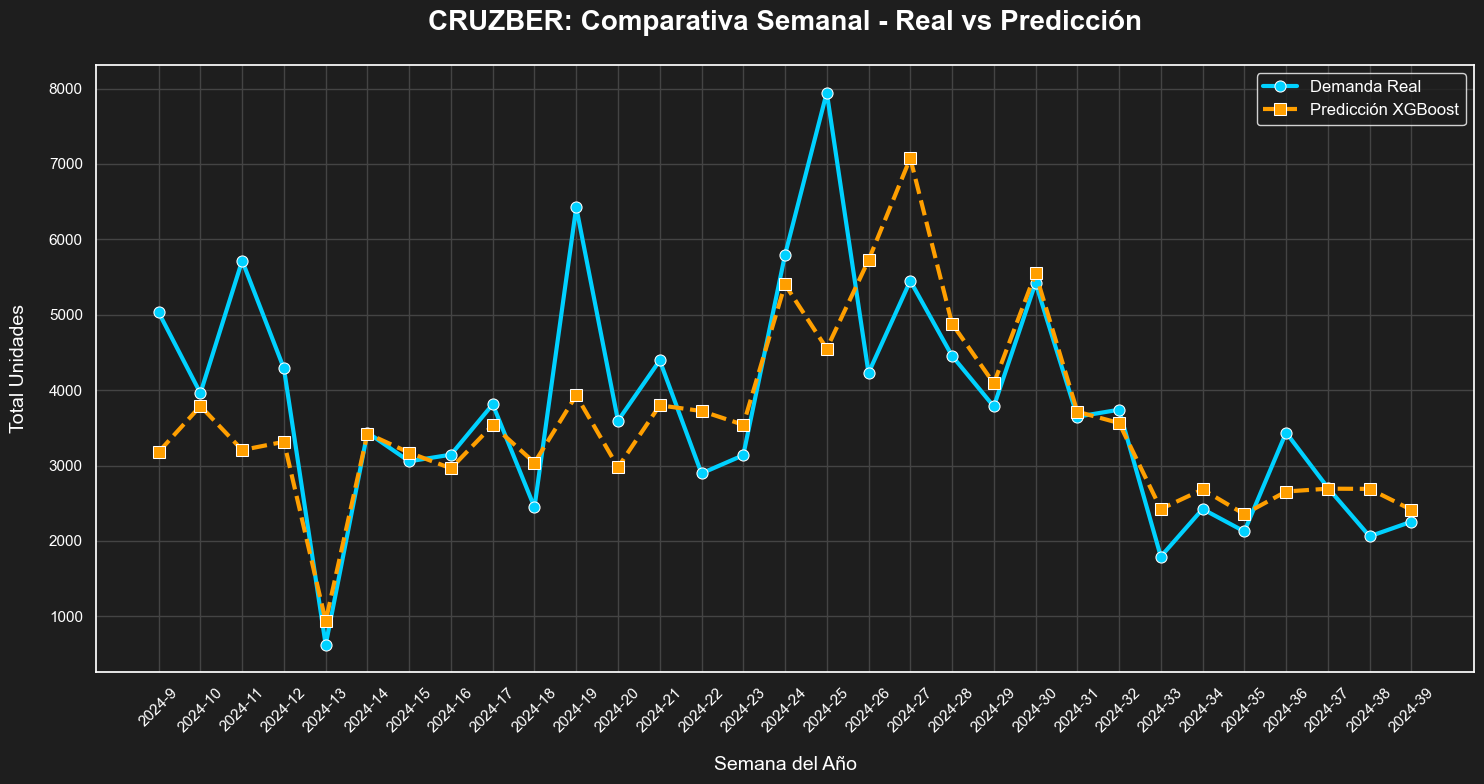

In [11]:
# 1. Configuración de estilo "Professional Dark"
sns.set_theme(style="darkgrid")
plt.rcParams['figure.facecolor'] = '#1e1e1e'
plt.rcParams['axes.facecolor'] = '#1e1e1e'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['grid.color'] = '#444444'

# 2. Preparación de los datos para la gráfica
# Agrupamos por semana para ver la tendencia general de la empresa
# Nota: 'test' es el dataframe que contiene tus resultados y la columna 'prediccion'
grafico_df = test.groupby('anio_semana').agg({
    'unidades': 'sum',
    'prediccion': 'sum'
}).reset_index()

# Ordenamos cronológicamente
grafico_df['sort_key'] = grafico_df['anio_semana'].apply(lambda x: int(x.split('-')[0])*100 + int(x.split('-')[1]))
grafico_df = grafico_df.sort_values('sort_key')

# 3. Creación del gráfico
plt.figure(figsize=(15, 8))

# Línea de Ventas Reales (Cian)
sns.lineplot(data=grafico_df, x='anio_semana', y='unidades', 
             label='Demanda Real', color='#00d1ff', linewidth=3, marker='o', markersize=8)

# Línea de Predicción (Naranja)
sns.lineplot(data=grafico_df, x='anio_semana', y='prediccion', 
             label='Predicción XGBoost', color='#ff9f00', linewidth=3, marker='s', markersize=8, linestyle='--')

# Personalización de etiquetas
plt.title('CRUZBER: Comparativa Semanal - Real vs Predicción', fontsize=20, fontweight='bold', pad=25)
plt.xlabel('Semana del Año', fontsize=14, labelpad=15)
plt.ylabel('Total Unidades', fontsize=14, labelpad=15)
plt.xticks(rotation=45)
plt.legend(fontsize=12, facecolor='#1e1e1e', edgecolor='white')

# Ajuste final y guardado
plt.tight_layout()
plt.savefig('visualizacion_resultados_cruzber.png', dpi=300)
# plt.show() # Descomenta esta línea si quieres verlo directamente en el notebook